# Importação de Bibliotecas

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregamento do Dataset

In [42]:
df = pd.read_csv('../data/data.csv')

# Visualizando as 5 primeiras linhas

In [43]:
df.head()

,area_m2,quartos,banheiros,vagas,bairro,idade_anos,piscina,preco
0,142,5,1,3,Jardins,38,0,1478740.51
1,146,2,3,2,Jardins,19,0,1385017.92
2,111,4,3,1,Vila Madalena,4,0,1303994.14
3,228,2,1,1,Jardins,0,0,1568554.71
4,60,3,1,3,Vila Madalena,29,0,795241.60


# Informações Gerais do Dataset

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_m2     500 non-null    int64  
 1   quartos     500 non-null    int64  
 2   banheiros   500 non-null    int64  
 3   vagas       500 non-null    int64  
 4   bairro      500 non-null    object 
 5   idade_anos  500 non-null    int64  
 6   piscina     500 non-null    int64  
 7   preco       500 non-null    float64
dtypes: float64(1), int64(6), object(1)
memory usage: 31.4+ KB


# Estatísticas Descritivas do Dataset 

In [45]:
df.describe()

,area_m2,quartos,banheiros,vagas,idade_anos,piscina,preco
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,5.000000e+02
mean,173.014000,3.096000,2.430000,1.464000,24.77000,0.312000,1.279756e+06
std,72.517276,1.495077,1.065538,1.109579,14.10571,0.463774,3.775765e+05
min,40.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.432965e+05
25%,107.000000,2.000000,2.000000,0.000000,13.00000,0.000000,1.022904e+06
50%,174.000000,3.000000,2.000000,1.000000,25.00000,0.000000,1.261277e+06
75%,230.000000,5.000000,3.000000,2.000000,36.25000,1.000000,1.558536e+06
max,299.000000,5.000000,4.000000,3.000000,49.00000,1.000000,2.378977e+06


# Verificação de Valores Nulos

In [46]:
df.isnull().sum()

area_m2       0
quartos       0
banheiros     0
vagas         0
bairro        0
idade_anos    0
piscina       0
preco         0
dtype: int64

# Número de linhas e de colunas

In [47]:
print(f'Número de linhas: {df.shape[0]}. Número de colunas: {df.shape[1]}')

Número de linhas: 500. Número de colunas: 8


# Paleta de cores

In [48]:
paleta = sns.color_palette('tab10')

# Como os preços dos imóveis estão distribuídos no dataset?

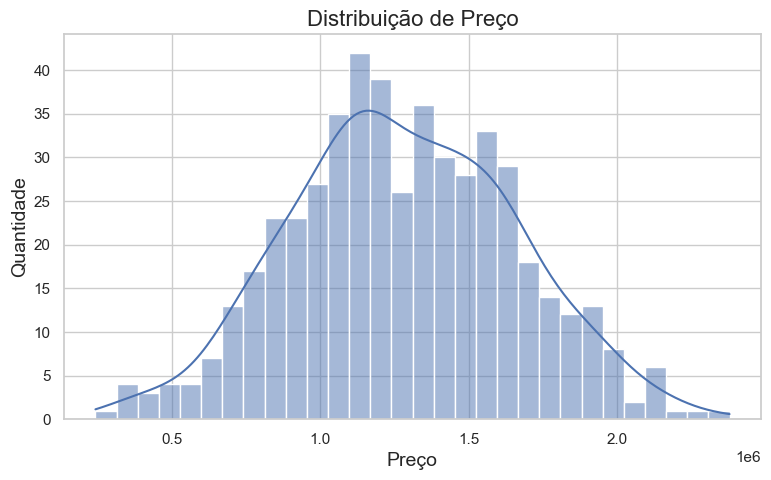

In [49]:
sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.histplot(data=df['preco'], kde=True, bins=30)
ax.set_title('Distribuição de Preço', fontsize=16)
ax.set_xlabel('Preço', fontsize=14)
ax.set_ylabel('Quantidade', fontsize=14)

plt.show()

# Existem outliers na váriavel preço e como os valores estão dispersos?

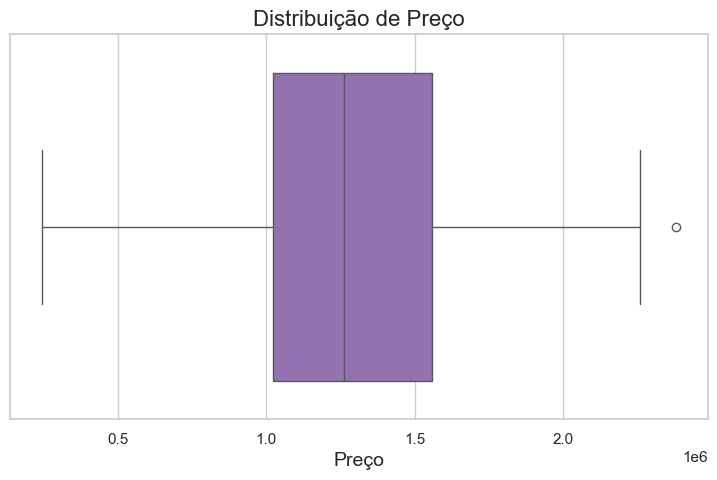

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.boxplot(x=df['preco'], color=paleta[4])
ax.set_title('Distribuição de Preço', fontsize=16)
ax.set_xlabel('Preço', fontsize=14)

plt.show()

# Quais váriaveis tem maior influência sobre o preço do imóvel?

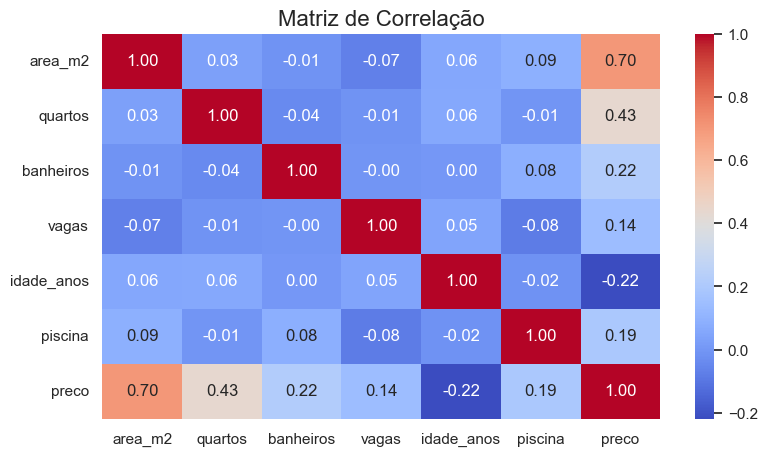

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
ax.set_title('Matriz de Correlação', fontsize=16)

plt.show()

# A área e o bairro são suficientes para explicar a variação do preço dos imóveis?

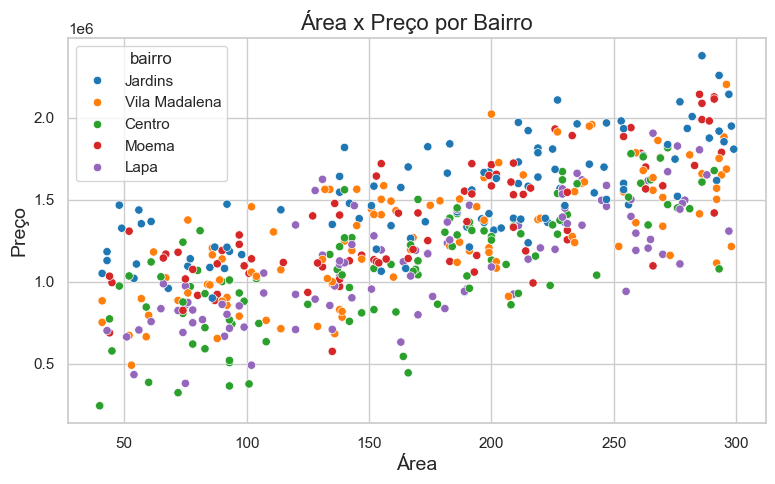

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.scatterplot(data=df, x='area_m2', y='preco', hue='bairro', palette='tab10')
ax.set_title('Área x Preço por Bairro', fontsize=16)
ax.set_xlabel('Área', fontsize=14)
ax.set_ylabel('Preço', fontsize=14)

plt.show()

# Qual o preço médio de cada bairro?

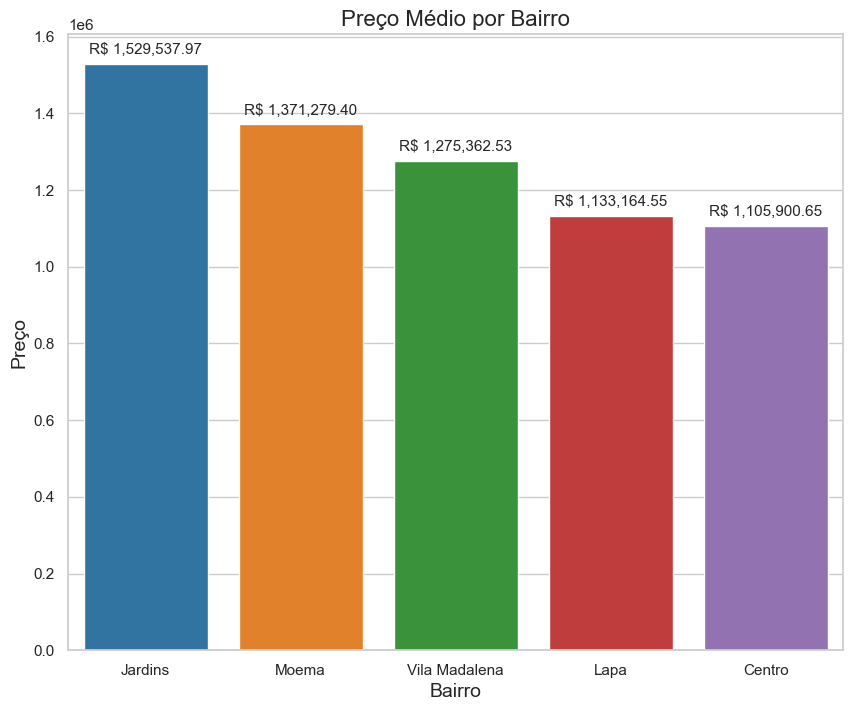

In [53]:
preco_medio = df.groupby('bairro', as_index=False)['preco'].mean().sort_values(by='preco', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(data=preco_medio, x='bairro', y='preco', palette='tab10', hue='bairro')
ax.set_title('Preço Médio por Bairro', fontsize=16)
ax.set_xlabel('Bairro', fontsize=14)
ax.set_ylabel('Preço', fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt='R$ {:,.2f}', fontsize=11, padding=5)

plt.show()

# Pré-processamento

In [54]:
df_ml = df.copy()

df_ml = df_ml.drop_duplicates()
df_ml = df_ml.dropna()

le = LabelEncoder()
df_ml['bairro'] = le.fit_transform(df_ml['bairro'])

X = df_ml.drop('preco', axis=1)
y = df_ml['preco']

print('Features: ', X.columns.tolist())
print('Shape X:', X.shape)

Features:  ['area_m2', 'quartos', 'banheiros', 'vagas', 'bairro', 'idade_anos', 'piscina']
Shape X: (500, 7)


# Divisão treino/teste

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (400, 7) | Teste: (100, 7)


# Treinar os Modelos

In [56]:
modelos = {
    'Linear Regression':  (LinearRegression(),                                              X_train_s, X_test_s),
    'Ridge Regression':   (Ridge(alpha=10),                                                 X_train_s, X_test_s),
    'Random Forest':      (RandomForestRegressor(n_estimators=100, random_state=42),        X_train,   X_test),
    'Gradient Boosting':  (GradientBoostingRegressor(n_estimators=100, random_state=42),    X_train,   X_test),
}

resultados = {}

for nome, (modelo, X_tr, X_te) in modelos.items():
    modelo.fit(X_tr, y_train)
    pred = modelo.predict(X_te)
    resultados[nome] = {
        'MAE': round(mean_absolute_error(y_test, pred), 2),
        'RMSE': round(mean_squared_error(y_test, pred) ** 0.5, 2),
        'R²': round(r2_score(y_test, pred), 4),
    }

resultado_df = pd.DataFrame(resultados).T
print(resultado_df)

                         MAE       RMSE      R²
Linear Regression  119343.57  137002.69  0.8526
Ridge Regression   120036.83  137626.86  0.8512
Random Forest      125297.56  156024.70  0.8088
Gradient Boosting   69240.02   88363.92  0.9387


# Comparar os Modelos

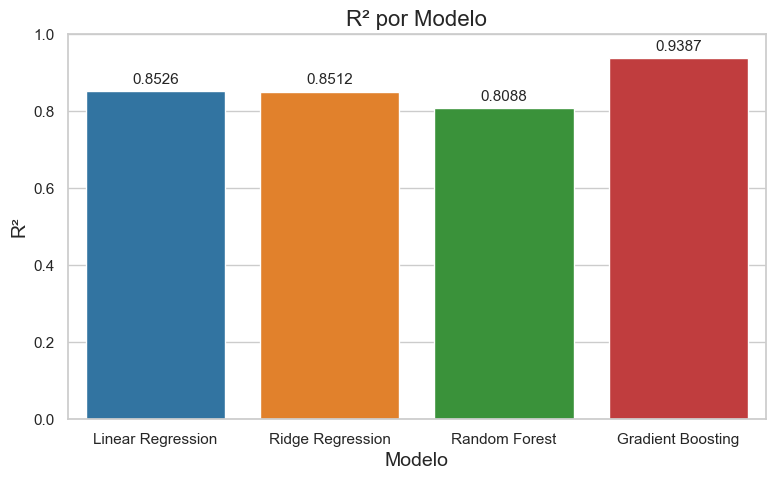

Melhor modelo: Gradient Boosting
MAE     69240.0200
RMSE    88363.9200
R²          0.9387
Name: Gradient Boosting, dtype: float64


In [57]:
fig, ax = plt.subplots(figsize=(9, 5))
ax = sns.barplot(x=resultado_df.index, y=resultado_df['R²'], palette='tab10', hue=resultado_df.index)
ax.set_title('R² por Modelo', fontsize=16)
ax.set_xlabel('Modelo', fontsize=14)
ax.set_ylabel('R²', fontsize=14)
ax.set_ylim(0, 1.0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=11, padding=3)

plt.show()

melhor_nome = resultado_df['R²'].idxmax()
print(f'Melhor modelo: {melhor_nome}')
print(resultado_df.loc[melhor_nome])

# Feature Importance

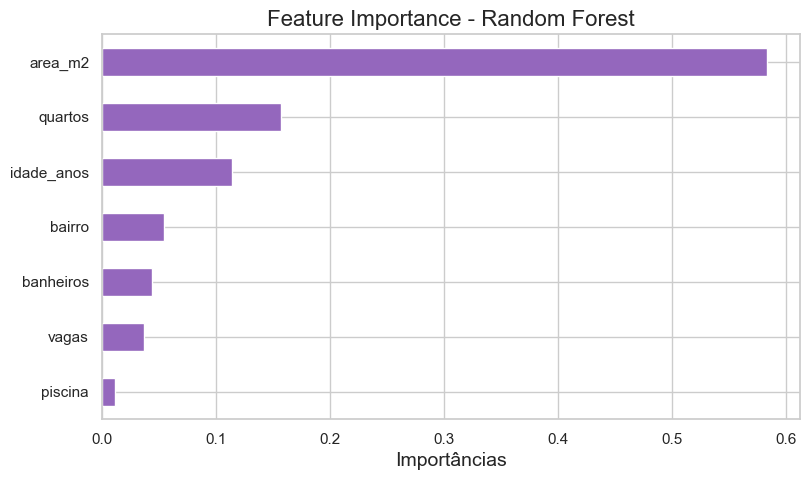

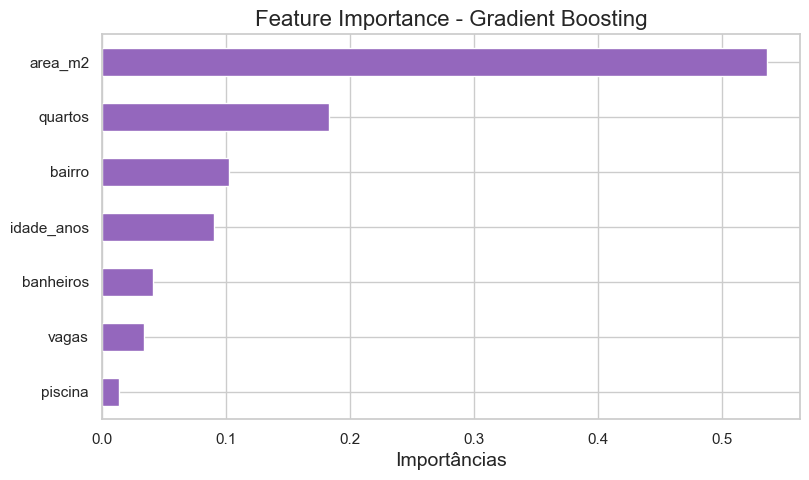

In [58]:
for nome in ['Random Forest', 'Gradient Boosting']:
    modelo = modelos[nome][0]
    importancias = pd.Series(
        modelo.feature_importances_, index=X.columns
    ).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    importancias.plot(kind='barh', ax=ax, color=paleta[4])
    ax.set_title(f'Feature Importance - {nome}', fontsize=16)
    ax.set_xlabel('Importâncias', fontsize=14)

    plt.show()

# Desempenho por Modelos

In [59]:
print("=" * 45)
print(f"{'Modelo':<25} {'R² Treino':>10} {'R² Teste':>10}")
print("=" * 45)

for nome, (modelo, X_tr, X_te) in modelos.items():
    r2_treino = r2_score(y_train, modelo.predict(X_tr))
    r2_teste = r2_score(y_test, modelo.predict(X_te))
    print(f"{nome:<25} {r2_treino:>10.4f} {r2_teste:>10.4f}")

print("=" * 45)

Modelo                     R² Treino   R² Teste
Linear Regression             0.8634     0.8526
Ridge Regression              0.8629     0.8512
Random Forest                 0.9763     0.8088
Gradient Boosting             0.9902     0.9387


# Predição - Novo Imóvel

In [60]:
melhor_modelo = modelos[melhor_nome][0]
usa_scaler    = melhor_nome in ['Linear Regression', 'Ridge Regression']

novo_imovel = pd.DataFrame([{
    'area_m2':    140,
    'quartos':    3,
    'banheiros':  2,
    'vagas':      1,
    'bairro':     le.transform(['Centro'])[0],
    'idade_anos': 5,
    'piscina':    1,
}])

entrada = scaler.transform(novo_imovel) if usa_scaler else novo_imovel
pred    = melhor_modelo.predict(entrada)[0]

pred_teste = melhor_modelo.predict(X_test_s if usa_scaler else X_test)
mae  = mean_absolute_error(y_test, pred_teste)
rmse = mean_squared_error(y_test, pred_teste) ** 0.5
r2   = r2_score(y_test, pred_teste)

print(f"🏠 Preço previsto: R$ {pred:,.2f}")
print(f"\nPrecisão do modelo ({melhor_nome}):")
print(f"R²: {r2:.4f}")
print(f"MAE: R$ {mae:,.2f}")
print(f"RMSE: R$ {rmse:,.2f}")

🏠 Preço previsto: R$ 1,092,331.99

Precisão do modelo (Gradient Boosting):
R²: 0.9387
MAE: R$ 69,240.02
RMSE: R$ 88,363.92


# Salvar o Modelo